# 07 Sensitivity Analysis

The Monte Carlo simulation and dependency modelling notebooks estimate the system response under uncertainty. This notebook asks a different question:

```text
Which assumptions and load rows are most responsible for the high-risk outcomes?
```

This stage is deliberately split into two levels:

* **scenario sensitivity**, using the summary outputs already generated in Notebooks 05 and 06;
* **item-level sensitivity**, using a focused simulation of the most constrained case from Notebook 06.

The item-level simulation is needed because the earlier notebooks saved subsystem summaries rather than every sampled load row.


## Why the focused case is used

Notebook 06 showed that the independent baseline did not produce overloads, but strong positive dependency did change the risk result. The most constrained case was:

| Setting | Value |
|---|---|
| Scenario | Scenario Bravo |
| Uncertainty case | Case C - CMM + CUM + DBM + IGM |
| Distribution | Truncated normal |
| Dependency model | Global Gaussian copula |
| Latent correlation | $\rho = 0.75$ |
| Target subsystem | FW |

I focus the item-level sensitivity analysis on this case because it is the first part of the modelling chain where overloads are frequent enough to analyse statistically. Applying logistic regression to no-overload cases would not be meaningful because the response variable would contain only one class. For the no-overload settings, scenario-level sensitivity and high-percentile load metrics are more appropriate.


## Imports and paths


In [1]:
from pathlib import Path
import math
import warnings

import numpy as np
import pandas as pd

try:
    import matplotlib.pyplot as plt
    import seaborn as sns
    plotting_available = True
except ModuleNotFoundError:
    plotting_available = False

try:
    from scipy.special import ndtr
    from scipy.stats import rankdata, truncnorm
    scipy_available = True
except ModuleNotFoundError:
    scipy_available = False

try:
    from sklearn.linear_model import LogisticRegression
    from sklearn.metrics import roc_auc_score
    from sklearn.preprocessing import StandardScaler
    sklearn_available = True
except ModuleNotFoundError:
    sklearn_available = False

warnings.filterwarnings("ignore", category=FutureWarning)


def find_project_root():
    candidates = [Path.cwd(), *Path.cwd().parents]
    for candidate in candidates:
        if (
            (candidate / "outputs" / "tables" / "dependency_results_summary.csv").exists()
            and (candidate / "outputs" / "tables" / "uncertainty_distribution_parameters.csv").exists()
        ):
            return candidate
    raise FileNotFoundError("Could not find the project root. Please open VS Code at the repository folder.")


project_root = find_project_root()
tables_output_path = project_root / "outputs" / "tables"
figures_output_path = project_root / "outputs" / "figures"
tables_output_path.mkdir(parents=True, exist_ok=True)
figures_output_path.mkdir(parents=True, exist_ok=True)

print(f"Project root: {project_root}")
print(f"Tables output path: {tables_output_path}")
print(f"Figures output path: {figures_output_path}")


Project root: C:\Users\hburg\Documents\Codex\2026-06-26\github-plugin-github-openai-curated-remote\work\Monte-Carlo-Simulation-of-a-Cascading-Cooling-System
Tables output path: C:\Users\hburg\Documents\Codex\2026-06-26\github-plugin-github-openai-curated-remote\work\Monte-Carlo-Simulation-of-a-Cascading-Cooling-System\outputs\tables
Figures output path: C:\Users\hburg\Documents\Codex\2026-06-26\github-plugin-github-openai-curated-remote\work\Monte-Carlo-Simulation-of-a-Cascading-Cooling-System\outputs\figures


## Load previous-stage outputs


In [2]:
distribution_parameters = pd.read_csv(tables_output_path / "uncertainty_distribution_parameters.csv")
monte_carlo_results = pd.read_csv(tables_output_path / "monte_carlo_results_summary.csv")
dependency_results = pd.read_csv(tables_output_path / "dependency_results_summary.csv")
dependency_comparison = pd.read_csv(tables_output_path / "dependency_comparison_to_independent.csv")

system_order = ["HVAC", "CW", "FW"]
scenario_order = ["Scenario Alpha", "Scenario Bravo"]
margin_case_order = [
    "Case A - CUM",
    "Case B - CMM + CUM",
    "Case C - CMM + CUM + DBM + IGM",
]
distribution_order = ["Triangular", "Truncated normal"]

print(f"Uncertainty parameter rows: {len(distribution_parameters):,}")
print(f"Independent Monte Carlo result rows: {len(monte_carlo_results):,}")
print(f"Dependency result rows: {len(dependency_results):,}")
display(dependency_results.head())


Uncertainty parameter rows: 15,534
Independent Monte Carlo result rows: 36
Dependency result rows: 216


,scenario,margin_case,distribution_model,dependency_model,rho,subsystem,simulations,deterministic_load_kw,capacity_kw,mean_load_kw,...,p99_load_to_capacity_ratio,max_load_to_capacity_ratio,p95_capacity_margin_pct,p99_capacity_margin_pct,overload_count,overload_probability,overload_probability_pct,overload_probability_ci95_lower,overload_probability_ci95_upper,rule_of_three_upper_if_zero
0,Scenario Alpha,Case A - CUM,Triangular,Global Gaussian copula,0.25,CW,100000,3814.611478,4068.06,3814.656131,...,0.946406,0.951726,5.595961,5.359441,0,0.0,0.0,0.0,0.0,0.00003
1,Scenario Alpha,Case A - CUM,Triangular,Global Gaussian copula,0.25,FW,100000,11172.365578,11734.66,11172.410231,...,0.955101,0.956946,4.571866,4.489872,0,0.0,0.0,0.0,0.0,0.00003
2,Scenario Alpha,Case A - CUM,Triangular,Global Gaussian copula,0.25,HVAC,100000,1026.733447,1159.42,1026.746891,...,0.893142,0.896991,10.896289,10.685783,0,0.0,0.0,0.0,0.0,0.00003
3,Scenario Alpha,Case A - CUM,Triangular,Global Gaussian copula,0.50,CW,100000,3814.611478,4068.06,3814.626122,...,0.949547,0.955037,5.344772,5.045270,0,0.0,0.0,0.0,0.0,0.00003
4,Scenario Alpha,Case A - CUM,Triangular,Global Gaussian copula,0.50,FW,100000,11172.365578,11734.66,11172.380222,...,0.956190,0.958094,4.484786,4.380958,0,0.0,0.0,0.0,0.0,0.00003


## Sensitivity settings


In [3]:
FOCUS_SCENARIO = "Scenario Bravo"
FOCUS_MARGIN_CASE = "Case C - CMM + CUM + DBM + IGM"
FOCUS_DISTRIBUTION = "Truncated normal"
FOCUS_DEPENDENCY_MODEL = "Global Gaussian copula"
FOCUS_RHO = 0.75
FOCUS_SUBSYSTEM = "FW"

N_SENSITIVITY_SIMULATIONS = 100_000
RANDOM_SEED = 19046600 + 7
TOP_FEATURE_COUNT = 30

sensitivity_settings = pd.DataFrame([
    {"Parameter": "Focused scenario", "Value": FOCUS_SCENARIO},
    {"Parameter": "Focused uncertainty case", "Value": FOCUS_MARGIN_CASE},
    {"Parameter": "Focused distribution", "Value": FOCUS_DISTRIBUTION},
    {"Parameter": "Focused dependency model", "Value": FOCUS_DEPENDENCY_MODEL},
    {"Parameter": "Focused latent correlation", "Value": FOCUS_RHO},
    {"Parameter": "Target subsystem", "Value": FOCUS_SUBSYSTEM},
    {"Parameter": "Sensitivity simulations", "Value": f"{N_SENSITIVITY_SIMULATIONS:,}"},
    {"Parameter": "Random seed", "Value": RANDOM_SEED},
    {"Parameter": "Top features used in logistic regression", "Value": TOP_FEATURE_COUNT},
])

sensitivity_settings.to_csv(tables_output_path / "sensitivity_simulation_settings.csv", index=False)
display(sensitivity_settings)


,Parameter,Value
0,Focused scenario,Scenario Bravo
1,Focused uncertainty case,Case C - CMM + CUM + DBM + IGM
2,Focused distribution,Truncated normal
3,Focused dependency model,Global Gaussian copula
4,Focused latent correlation,0.75
5,Target subsystem,FW
6,Sensitivity simulations,"100,000"
7,Random seed,19046607
8,Top features used in logistic regression,30


## Scenario sensitivity

The scenario sensitivity section uses the outputs from Notebooks 05 and 06. This is the right level for comparing modelling assumptions such as distribution type, uncertainty case, dependency structure and correlation strength.

The main response metric is the P99 load-to-capacity ratio, because overload probability alone was not informative in the independent baseline.


In [4]:
independent_for_sensitivity = monte_carlo_results.copy()
independent_for_sensitivity["dependency_model"] = "Independent"
independent_for_sensitivity["rho"] = 0.0

scenario_sensitivity = pd.concat([
    independent_for_sensitivity[[
        "scenario",
        "margin_case",
        "distribution_model",
        "dependency_model",
        "rho",
        "subsystem",
        "p99_load_to_capacity_ratio",
        "p99_spare_capacity_kw",
        "overload_probability_pct",
    ]],
    dependency_results[[
        "scenario",
        "margin_case",
        "distribution_model",
        "dependency_model",
        "rho",
        "subsystem",
        "p99_load_to_capacity_ratio",
        "p99_spare_capacity_kw",
        "overload_probability_pct",
    ]],
], ignore_index=True)

scenario_sensitivity = scenario_sensitivity.sort_values(
    ["p99_load_to_capacity_ratio", "overload_probability_pct"],
    ascending=[False, False],
).reset_index(drop=True)

scenario_sensitivity.to_csv(tables_output_path / "sensitivity_scenario_comparison.csv", index=False)
display(scenario_sensitivity.head(20))


,scenario,margin_case,distribution_model,dependency_model,rho,subsystem,p99_load_to_capacity_ratio,p99_spare_capacity_kw,overload_probability_pct
0,Scenario Bravo,Case C - CMM + CUM + DBM + IGM,Truncated normal,Global Gaussian copula,0.75,FW,1.026979,-131.437759,9.225
1,Scenario Bravo,Case C - CMM + CUM + DBM + IGM,Truncated normal,Global Gaussian copula,0.75,CW,1.022912,-31.895599,4.077
2,Scenario Bravo,Case C - CMM + CUM + DBM + IGM,Triangular,Global Gaussian copula,0.75,FW,1.021097,-102.780623,7.035
3,Scenario Alpha,Case C - CMM + CUM + DBM + IGM,Truncated normal,Global Gaussian copula,0.75,FW,1.020210,-237.159811,6.942
4,Scenario Alpha,Case C - CMM + CUM + DBM + IGM,Truncated normal,Global Gaussian copula,0.75,CW,1.016671,-67.818855,4.488
5,Scenario Bravo,Case C - CMM + CUM + DBM + IGM,Truncated normal,Global Gaussian copula,0.50,FW,1.016172,-78.785242,5.116
6,Scenario Alpha,Case C - CMM + CUM + DBM + IGM,Triangular,Global Gaussian copula,0.75,FW,1.014237,-167.063648,5.077
7,Scenario Bravo,Case C - CMM + CUM + DBM + IGM,Triangular,Global Gaussian copula,0.75,CW,1.013280,-18.486471,2.558
8,Scenario Bravo,Case C - CMM + CUM + DBM + IGM,Triangular,Global Gaussian copula,0.50,FW,1.011560,-56.316754,3.592
9,Scenario Alpha,Case C - CMM + CUM + DBM + IGM,Truncated normal,Global Gaussian copula,0.50,FW,1.010666,-125.165389,3.457


## Focused item-level simulation


The item-level simulation is run only for the focused worst case. It uses the same Gaussian copula logic as Notebook 06, but stores the sampled item-level matrix so that item sensitivities can be calculated.

Only non-degenerate load rows are included as sensitivity features. Fixed zero or fixed nominal rows do not vary, so they cannot explain variation in the FW load.


In [5]:
if not scipy_available:
    raise ModuleNotFoundError("scipy is required for the focused item-level sensitivity simulation.")

focused_parameters = distribution_parameters[
    (distribution_parameters["scenario"] == FOCUS_SCENARIO) &
    (distribution_parameters["margin_case"] == FOCUS_MARGIN_CASE)
].copy()

fixed_parameters = focused_parameters[focused_parameters["is_degenerate"]].copy()
variable_parameters = focused_parameters[~focused_parameters["is_degenerate"]].copy().reset_index(drop=True)

print(f"Focused parameter rows: {len(focused_parameters):,}")
print(f"Variable sensitivity rows: {len(variable_parameters):,}")
display(variable_parameters.head())


Focused parameter rows: 2,589
Variable sensitivity rows: 447


,record_id,source_row,pbs_code,teamcenter_id,bom_id,item_description,system,scenario,margin_case,nominal_load_kw,uncertainty_pct,triangular_lower_kw,triangular_mode_kw,triangular_upper_kw,truncnorm_lower_kw,truncnorm_mean_kw,truncnorm_upper_kw,truncnorm_sigma_kw,is_degenerate
0,2,1,PBS_GROUP_0001,NaN,BOM_000002,ITEM_000002,CW,Scenario Bravo,Case C - CMM + CUM + DBM + IGM,9.668000,0.35,6.284200,9.668000,13.05180,6.284200,9.668000,13.05180,1.726429,False
1,3,2,PBS_GROUP_0001,NaN,BOM_000003,ITEM_000003,CW,Scenario Bravo,Case C - CMM + CUM + DBM + IGM,9.368000,0.35,6.089200,9.368000,12.64680,6.089200,9.368000,12.64680,1.672857,False
2,4,3,PBS_GROUP_0001,NaN,BOM_000004,ITEM_000004,CW,Scenario Bravo,Case C - CMM + CUM + DBM + IGM,1.500141,0.35,0.975092,1.500141,2.02519,0.975092,1.500141,2.02519,0.267882,False
3,5,4,PBS_GROUP_0001,NaN,BOM_000005,ITEM_000005,CW,Scenario Bravo,Case C - CMM + CUM + DBM + IGM,3.638000,0.35,2.364700,3.638000,4.91130,2.364700,3.638000,4.91130,0.649643,False
4,6,5,PBS_GROUP_0001,NaN,BOM_000006,ITEM_000006,CW,Scenario Bravo,Case C - CMM + CUM + DBM + IGM,3.692000,0.35,2.399800,3.692000,4.98420,2.399800,3.692000,4.98420,0.659286,False


In [6]:
rng = np.random.default_rng(RANDOM_SEED)

common_factor = rng.standard_normal(N_SENSITIVITY_SIMULATIONS)
independent_noise = rng.standard_normal(size=(len(variable_parameters), N_SENSITIVITY_SIMULATIONS))
latent_normal = (
    math.sqrt(FOCUS_RHO) * common_factor[None, :] +
    math.sqrt(1 - FOCUS_RHO) * independent_noise
)
probabilities = np.clip(ndtr(latent_normal), 1e-12, 1 - 1e-12)

mean = variable_parameters["truncnorm_mean_kw"].to_numpy(dtype=float)[:, None]
lower = variable_parameters["truncnorm_lower_kw"].to_numpy(dtype=float)[:, None]
upper = variable_parameters["truncnorm_upper_kw"].to_numpy(dtype=float)[:, None]
sigma = variable_parameters["truncnorm_sigma_kw"].to_numpy(dtype=float)[:, None]

a = (lower - mean) / sigma
b = (upper - mean) / sigma

item_samples = truncnorm.ppf(
    probabilities,
    a,
    b,
    loc=mean,
    scale=sigma,
).astype(np.float32)

del independent_noise, latent_normal, probabilities

local_totals = {}
for system in system_order:
    fixed_total = fixed_parameters.loc[fixed_parameters["system"] == system, "nominal_load_kw"].sum()
    variable_mask = variable_parameters["system"].to_numpy() == system
    local_totals[system] = fixed_total + item_samples[variable_mask].sum(axis=0)

hvac_total = local_totals["HVAC"]
cw_total = local_totals["CW"] + hvac_total
fw_total = local_totals["FW"] + cw_total

target_load = fw_total
target_capacity = dependency_results[
    (dependency_results["scenario"] == FOCUS_SCENARIO) &
    (dependency_results["margin_case"] == FOCUS_MARGIN_CASE) &
    (dependency_results["distribution_model"] == FOCUS_DISTRIBUTION) &
    (dependency_results["dependency_model"] == FOCUS_DEPENDENCY_MODEL) &
    (dependency_results["rho"] == FOCUS_RHO) &
    (dependency_results["subsystem"] == FOCUS_SUBSYSTEM)
]["capacity_kw"].iloc[0]

target_overload = target_load > target_capacity

focused_simulation_check = pd.DataFrame([{
    "scenario": FOCUS_SCENARIO,
    "margin_case": FOCUS_MARGIN_CASE,
    "distribution_model": FOCUS_DISTRIBUTION,
    "dependency_model": FOCUS_DEPENDENCY_MODEL,
    "rho": FOCUS_RHO,
    "subsystem": FOCUS_SUBSYSTEM,
    "simulations": N_SENSITIVITY_SIMULATIONS,
    "capacity_kw": target_capacity,
    "mean_load_kw": target_load.mean(),
    "p95_load_kw": np.percentile(target_load, 95),
    "p99_load_kw": np.percentile(target_load, 99),
    "overload_count": int(target_overload.sum()),
    "overload_probability_pct": target_overload.mean() * 100,
}])

focused_simulation_check.to_csv(tables_output_path / "sensitivity_focused_simulation_check.csv", index=False)
display(focused_simulation_check)


,scenario,margin_case,distribution_model,dependency_model,rho,subsystem,simulations,capacity_kw,mean_load_kw,p95_load_kw,p99_load_kw,overload_count,overload_probability_pct
0,Scenario Bravo,Case C - CMM + CUM + DBM + IGM,Truncated normal,Global Gaussian copula,0.75,FW,100000,4871.78,4636.095703,4917.761353,5001.091152,8992,8.992


## Spearman rank sensitivity


Spearman rank correlation is used because the relationship between an individual load row and the final FW load is monotonic but not necessarily linear. It is also less sensitive to scale than a simple covariance measure.

The response variable is the sampled FW cascaded load. The resulting ranking identifies load rows that move most strongly with the high FW load condition.


In [7]:
def spearman_against_target(feature_matrix, target):
    target_rank = rankdata(target)
    target_rank = (target_rank - target_rank.mean()) / target_rank.std(ddof=0)

    correlations = np.empty(feature_matrix.shape[0], dtype=float)
    for index in range(feature_matrix.shape[0]):
        feature_rank = rankdata(feature_matrix[index])
        feature_rank = (feature_rank - feature_rank.mean()) / feature_rank.std(ddof=0)
        correlations[index] = np.mean(feature_rank * target_rank)

    return correlations


spearman_fw_load = spearman_against_target(item_samples, target_load)
spearman_overload = spearman_against_target(item_samples, target_overload.astype(float))

item_summary = variable_parameters[[
    "record_id",
    "source_row",
    "pbs_code",
    "teamcenter_id",
    "bom_id",
    "item_description",
    "system",
    "nominal_load_kw",
    "uncertainty_pct",
]].copy()

item_summary["sample_mean_kw"] = item_samples.mean(axis=1)
item_summary["sample_p95_kw"] = np.percentile(item_samples, 95, axis=1)
item_summary["sample_p99_kw"] = np.percentile(item_samples, 99, axis=1)
item_summary["spearman_fw_load"] = spearman_fw_load
item_summary["spearman_overload"] = spearman_overload
item_summary["abs_spearman_fw_load"] = item_summary["spearman_fw_load"].abs()
item_summary["abs_spearman_overload"] = item_summary["spearman_overload"].abs()

item_summary = item_summary.sort_values("abs_spearman_fw_load", ascending=False).reset_index(drop=True)
item_summary.to_csv(tables_output_path / "sensitivity_item_level_summary.csv", index=False)

top_spearman = item_summary.head(25).copy()
top_spearman.to_csv(tables_output_path / "sensitivity_top_spearman_fw_load.csv", index=False)
display(top_spearman)


,record_id,source_row,pbs_code,teamcenter_id,bom_id,item_description,system,nominal_load_kw,uncertainty_pct,sample_mean_kw,sample_p95_kw,sample_p99_kw,spearman_fw_load,spearman_overload,abs_spearman_fw_load,abs_spearman_overload
0,76,75,PBS_GROUP_0006,TC_000009,BOM_000058,ITEM_000076,FW,886.459000,0.13,886.316162,972.041370,992.998259,0.922194,0.471254,0.922194,0.471254
1,439,438,PBS_GROUP_0017,TC_000372,BOM_000420,ITEM_000418,FW,692.261492,0.08,692.339294,733.418390,743.547574,0.879246,0.454783,0.879246,0.454783
2,84,83,PBS_GROUP_0009,TC_000017,BOM_000066,ITEM_000083,FW,111.398997,0.13,111.394989,122.119136,124.816690,0.852269,0.445864,0.852269,0.445864
3,820,819,PBS_GROUP_SMALL,TC_000753,BOM_000800,ITEM_000788,CW,74.609229,0.18,74.584503,84.552565,87.042764,0.851158,0.444855,0.851158,0.444855
4,1683,1682,PBS_GROUP_SMALL,TC_001616,BOM_001658,ITEM_001333,FW,100.134570,0.13,100.138107,109.783185,112.184123,0.849527,0.442819,0.849527,0.442819
5,1190,1189,PBS_GROUP_0034,TC_001123,BOM_001169,ITEM_001098,CW,83.136000,0.14,83.125847,91.733395,93.895566,0.847944,0.441801,0.847944,0.441801
6,1025,1024,PBS_GROUP_SMALL,TC_000958,BOM_001004,ITEM_000984,CW,59.805000,0.14,59.799335,66.030688,67.575144,0.846842,0.442395,0.846842,0.442395
7,1024,1023,PBS_GROUP_SMALL,TC_000957,BOM_001003,ITEM_000983,CW,64.127000,0.14,64.122742,70.762811,72.467591,0.846532,0.442785,0.846532,0.442785
8,1201,1200,PBS_GROUP_0033,TC_001134,BOM_001177,ITEM_001109,FW,76.558000,0.08,76.548866,81.084048,82.223582,0.846525,0.442245,0.846525,0.442245
9,62,61,PBS_GROUP_0001,NaN,BOM_000044,ITEM_000062,CW,22.286000,0.35,22.280254,28.052873,29.506450,0.846473,0.441476,0.846473,0.441476


## Consumer influence screening

The Spearman table is treated as the consumer-screening part of the DoE-style sensitivity workflow. Each row is a consumer/load item and the response is the final cascaded FW load from the focused simulation.

I use this screening step before the fractional factorial section because the full factorial design is better suited to comparing modelling assumptions, while the item-level simulation is better suited to identifying individual consumers. This keeps the interpretation aligned with the project aim without using DoE to estimate failure probability.


In [8]:
consumer_screening = top_spearman[[
    "item_description",
    "system",
    "nominal_load_kw",
    "uncertainty_pct",
    "sample_p99_kw",
    "spearman_fw_load",
    "spearman_overload",
]].copy()

consumer_screening["consumer_rank"] = np.arange(1, len(consumer_screening) + 1)
consumer_screening = consumer_screening[[
    "consumer_rank",
    "item_description",
    "system",
    "nominal_load_kw",
    "uncertainty_pct",
    "sample_p99_kw",
    "spearman_fw_load",
    "spearman_overload",
]]

consumer_screening.to_csv(tables_output_path / "sensitivity_consumer_screening.csv", index=False)
display(consumer_screening.head(15))


,consumer_rank,item_description,system,nominal_load_kw,uncertainty_pct,sample_p99_kw,spearman_fw_load,spearman_overload
0,1,ITEM_000076,FW,886.459000,0.13,992.998259,0.922194,0.471254
1,2,ITEM_000418,FW,692.261492,0.08,743.547574,0.879246,0.454783
2,3,ITEM_000083,FW,111.398997,0.13,124.816690,0.852269,0.445864
3,4,ITEM_000788,CW,74.609229,0.18,87.042764,0.851158,0.444855
4,5,ITEM_001333,FW,100.134570,0.13,112.184123,0.849527,0.442819
5,6,ITEM_001098,CW,83.136000,0.14,93.895566,0.847944,0.441801
6,7,ITEM_000984,CW,59.805000,0.14,67.575144,0.846842,0.442395
7,8,ITEM_000983,CW,64.127000,0.14,72.467591,0.846532,0.442785
8,9,ITEM_001109,FW,76.558000,0.08,82.223582,0.846525,0.442245
9,10,ITEM_000062,CW,22.286000,0.35,29.506450,0.846473,0.441476


## Logistic regression sensitivity model


Logistic regression is only used where overload events exist. This is why I apply it to the focused worst case rather than every scenario.

For a no-overload case, logistic regression would fail or become meaningless because there is no contrast between failed and non-failed simulations. In those settings, Spearman correlation and high-percentile load metrics remain the better sensitivity tools.

To keep the model interpretable and avoid fitting hundreds of correlated predictors, I use the top Spearman-ranked load rows as the candidate features.


In [9]:
if not sklearn_available:
    print("Skipping logistic regression because scikit-learn is not installed.")
    logistic_coefficients = pd.DataFrame()
    logistic_model_summary = pd.DataFrame()
else:
    if target_overload.nunique() if hasattr(target_overload, "nunique") else len(np.unique(target_overload)) < 2:
        print("Skipping logistic regression because the focused response has only one class.")
        logistic_coefficients = pd.DataFrame()
        logistic_model_summary = pd.DataFrame()
    else:
        top_feature_indices = item_summary.head(TOP_FEATURE_COUNT).index.to_numpy()
        # item_summary has been sorted, so recover feature rows by record_id/source_row.
        top_feature_keys = item_summary.head(TOP_FEATURE_COUNT)[["record_id", "source_row"]]
        feature_indices = []
        for _, key_row in top_feature_keys.iterrows():
            match = variable_parameters.index[
                (variable_parameters["record_id"] == key_row["record_id"]) &
                (variable_parameters["source_row"] == key_row["source_row"])
            ]
            feature_indices.append(int(match[0]))

        X = item_samples[feature_indices].T
        y = target_overload.astype(int)

        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)

        logistic_model = LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            solver="lbfgs",
        )
        logistic_model.fit(X_scaled, y)
        predicted_probability = logistic_model.predict_proba(X_scaled)[:, 1]

        logistic_model_summary = pd.DataFrame([{
            "features": len(feature_indices),
            "observations": len(y),
            "overload_events": int(y.sum()),
            "overload_probability_pct": y.mean() * 100,
            "training_auc": roc_auc_score(y, predicted_probability),
        }])

        logistic_coefficients = variable_parameters.iloc[feature_indices][[
            "record_id",
            "source_row",
            "pbs_code",
            "teamcenter_id",
            "bom_id",
            "item_description",
            "system",
            "nominal_load_kw",
            "uncertainty_pct",
        ]].copy()
        logistic_coefficients["standardised_coefficient"] = logistic_model.coef_[0]
        logistic_coefficients["odds_ratio_per_std"] = np.exp(logistic_coefficients["standardised_coefficient"])
        logistic_coefficients["abs_standardised_coefficient"] = logistic_coefficients["standardised_coefficient"].abs()
        logistic_coefficients = logistic_coefficients.sort_values(
            "abs_standardised_coefficient",
            ascending=False,
        ).reset_index(drop=True)

        logistic_model_summary.to_csv(tables_output_path / "sensitivity_logistic_model_summary.csv", index=False)
        logistic_coefficients.to_csv(tables_output_path / "sensitivity_logistic_regression_coefficients.csv", index=False)

display(logistic_model_summary)
display(logistic_coefficients.head(20))


,features,observations,overload_events,overload_probability_pct,training_auc
0,30,100000,8992,8.992,0.999812


,record_id,source_row,pbs_code,teamcenter_id,bom_id,item_description,system,nominal_load_kw,uncertainty_pct,standardised_coefficient,odds_ratio_per_std,abs_standardised_coefficient
0,76,75,PBS_GROUP_0006,TC_000009,BOM_000058,ITEM_000076,FW,886.459000,0.13,15.264248,4.257735e+06,15.264248
1,439,438,PBS_GROUP_0017,TC_000372,BOM_000420,ITEM_000418,FW,692.261492,0.08,7.623934,2.046597e+03,7.623934
2,84,83,PBS_GROUP_0009,TC_000017,BOM_000066,ITEM_000083,FW,111.398997,0.13,2.563577,1.298217e+01,2.563577
3,820,819,PBS_GROUP_SMALL,TC_000753,BOM_000800,ITEM_000788,CW,74.609229,0.18,2.356366,1.055254e+01,2.356366
4,1683,1682,PBS_GROUP_SMALL,TC_001616,BOM_001658,ITEM_001333,FW,100.134570,0.13,2.133206,8.441887e+00,2.133206
5,1024,1023,PBS_GROUP_SMALL,TC_000957,BOM_001003,ITEM_000983,CW,64.127000,0.14,1.920851,6.826769e+00,1.920851
6,1190,1189,PBS_GROUP_0034,TC_001123,BOM_001169,ITEM_001098,CW,83.136000,0.14,1.830627,6.237798e+00,1.830627
7,62,61,PBS_GROUP_0001,NaN,BOM_000044,ITEM_000062,CW,22.286000,0.35,1.619113,5.048609e+00,1.619113
8,153,152,PBS_GROUP_SMALL,TC_000086,BOM_000134,ITEM_000132,HVAC,48.583000,0.14,1.446480,4.248136e+00,1.446480
9,64,63,PBS_GROUP_0001,NaN,BOM_000046,ITEM_000064,CW,20.404000,0.35,1.433507,4.193378e+00,1.433507


## Fractional factorial Design of Experiments


A fractional factorial Design of Experiments is included because it was part of the project proposal. In this notebook I use DoE as an interpretation tool, not as a method for estimating failure probabilities.

The sensitivity work is split into two linked parts:

* The item-level screening above identifies the consumers that have the strongest influence on the FW load response.
* The fractional factorial design below screens the modelling assumptions and selected interactions that move the system closer to, or further from, the capacity limit.

The dependency results already contain a larger simulation grid, so I use a two-level half-fraction selected from those results rather than running new simulations. The response is FW P99 load-to-capacity ratio. This response is used because the purpose is to compare proximity to the capacity limit, not to re-estimate overload probability.

The five two-level factors are:

| Factor | Low level (-1) | High level (+1) |
|---|---|---|
| Scenario | Scenario Alpha | Scenario Bravo |
| Uncertainty case | Case A | Case C |
| Distribution | Triangular | Truncated normal |
| Dependency model | Subsystem-block Gaussian copula | Global Gaussian copula |
| Correlation | $\rho = 0.25$ | $\rho = 0.75$ |

I use the half-fraction generator $E = ABCD$. This gives 16 runs and estimates the main effects. I also calculate a small set of selected two-factor interactions that are most relevant to the engineering question: whether uncertainty case, dependency structure, scenario and correlation combine to push FW closer to capacity.


In [10]:
doe_source = dependency_results[
    (dependency_results["subsystem"] == "FW") &
    (dependency_results["scenario"].isin(["Scenario Alpha", "Scenario Bravo"])) &
    (dependency_results["margin_case"].isin(["Case A - CUM", "Case C - CMM + CUM + DBM + IGM"])) &
    (dependency_results["distribution_model"].isin(["Triangular", "Truncated normal"])) &
    (dependency_results["dependency_model"].isin(["Subsystem-block Gaussian copula", "Global Gaussian copula"])) &
    (dependency_results["rho"].isin([0.25, 0.75]))
].copy()

coding_maps = {
    "scenario_code": {"Scenario Alpha": -1, "Scenario Bravo": 1},
    "margin_case_code": {"Case A - CUM": -1, "Case C - CMM + CUM + DBM + IGM": 1},
    "distribution_code": {"Triangular": -1, "Truncated normal": 1},
    "dependency_code": {"Subsystem-block Gaussian copula": -1, "Global Gaussian copula": 1},
    "rho_code": {0.25: -1, 0.75: 1},
}

doe_source["scenario_code"] = doe_source["scenario"].map(coding_maps["scenario_code"])
doe_source["margin_case_code"] = doe_source["margin_case"].map(coding_maps["margin_case_code"])
doe_source["distribution_code"] = doe_source["distribution_model"].map(coding_maps["distribution_code"])
doe_source["dependency_code"] = doe_source["dependency_model"].map(coding_maps["dependency_code"])
doe_source["rho_code"] = doe_source["rho"].map(coding_maps["rho_code"])

doe_source["generator_rho_code"] = (
    doe_source["scenario_code"] *
    doe_source["margin_case_code"] *
    doe_source["distribution_code"] *
    doe_source["dependency_code"]
)

fractional_factorial_design = doe_source[
    doe_source["rho_code"] == doe_source["generator_rho_code"]
].copy()

effect_columns = {
    "scenario_code": "Scenario: Bravo vs Alpha",
    "margin_case_code": "Uncertainty case: Case C vs Case A",
    "distribution_code": "Distribution: truncated normal vs triangular",
    "dependency_code": "Dependency: global vs subsystem-block",
    "rho_code": "Correlation: rho 0.75 vs rho 0.25",
}

effect_rows = []
for column, label in effect_columns.items():
    high_mean = fractional_factorial_design.loc[
        fractional_factorial_design[column] == 1,
        "p99_load_to_capacity_ratio",
    ].mean()
    low_mean = fractional_factorial_design.loc[
        fractional_factorial_design[column] == -1,
        "p99_load_to_capacity_ratio",
    ].mean()
    effect_rows.append({
        "term": label,
        "effect_type": "Main effect",
        "low_mean_response": low_mean,
        "high_mean_response": high_mean,
        "effect": high_mean - low_mean,
        "absolute_effect": abs(high_mean - low_mean),
    })

selected_interactions = {
    ("margin_case_code", "rho_code"): "Uncertainty case x correlation",
    ("dependency_code", "rho_code"): "Dependency model x correlation",
    ("scenario_code", "margin_case_code"): "Scenario x uncertainty case",
    ("margin_case_code", "dependency_code"): "Uncertainty case x dependency model",
    ("distribution_code", "rho_code"): "Distribution x correlation",
}

interaction_rows = []
for (left_column, right_column), label in selected_interactions.items():
    interaction_column = f"{left_column}_x_{right_column}"
    fractional_factorial_design[interaction_column] = (
        fractional_factorial_design[left_column] *
        fractional_factorial_design[right_column]
    )

    high_mean = fractional_factorial_design.loc[
        fractional_factorial_design[interaction_column] == 1,
        "p99_load_to_capacity_ratio",
    ].mean()
    low_mean = fractional_factorial_design.loc[
        fractional_factorial_design[interaction_column] == -1,
        "p99_load_to_capacity_ratio",
    ].mean()
    interaction_rows.append({
        "term": label,
        "effect_type": "Two-factor interaction",
        "low_mean_response": low_mean,
        "high_mean_response": high_mean,
        "effect": high_mean - low_mean,
        "absolute_effect": abs(high_mean - low_mean),
    })

doe_effects = pd.DataFrame(effect_rows).sort_values(
    "absolute_effect",
    ascending=False,
).reset_index(drop=True)

doe_interactions = pd.DataFrame(interaction_rows).sort_values(
    "absolute_effect",
    ascending=False,
).reset_index(drop=True)

doe_combined_effects = pd.concat(
    [doe_effects, doe_interactions],
    ignore_index=True,
).sort_values("absolute_effect", ascending=False).reset_index(drop=True)

fractional_factorial_design.to_csv(tables_output_path / "sensitivity_fractional_factorial_design.csv", index=False)
doe_effects.to_csv(tables_output_path / "sensitivity_fractional_factorial_effects.csv", index=False)
doe_interactions.to_csv(tables_output_path / "sensitivity_fractional_factorial_interactions.csv", index=False)
doe_combined_effects.to_csv(tables_output_path / "sensitivity_fractional_factorial_combined_effects.csv", index=False)

display(fractional_factorial_design[[
    "scenario",
    "margin_case",
    "distribution_model",
    "dependency_model",
    "rho",
    "p99_load_to_capacity_ratio",
    "scenario_code",
    "margin_case_code",
    "distribution_code",
    "dependency_code",
    "rho_code",
]])
display(doe_effects)
display(doe_interactions)


,scenario,margin_case,distribution_model,dependency_model,rho,p99_load_to_capacity_ratio,scenario_code,margin_case_code,distribution_code,dependency_code,rho_code
1,Scenario Alpha,Case A - CUM,Triangular,Global Gaussian copula,0.25,0.955101,-1,-1,-1,1,-1
16,Scenario Alpha,Case A - CUM,Triangular,Subsystem-block Gaussian copula,0.75,0.956031,-1,-1,-1,-1,1
25,Scenario Alpha,Case A - CUM,Truncated normal,Global Gaussian copula,0.75,0.957316,-1,-1,1,1,1
28,Scenario Alpha,Case A - CUM,Truncated normal,Subsystem-block Gaussian copula,0.25,0.954745,-1,-1,1,-1,-1
79,Scenario Alpha,Case C - CMM + CUM + DBM + IGM,Triangular,Global Gaussian copula,0.75,1.014237,-1,1,-1,1,1
82,Scenario Alpha,Case C - CMM + CUM + DBM + IGM,Triangular,Subsystem-block Gaussian copula,0.25,0.984064,-1,1,-1,-1,-1
91,Scenario Alpha,Case C - CMM + CUM + DBM + IGM,Truncated normal,Global Gaussian copula,0.25,0.997764,-1,1,1,1,-1
106,Scenario Alpha,Case C - CMM + CUM + DBM + IGM,Truncated normal,Subsystem-block Gaussian copula,0.75,0.999346,-1,1,1,-1,1
115,Scenario Bravo,Case A - CUM,Triangular,Global Gaussian copula,0.75,0.959430,1,-1,-1,1,1
118,Scenario Bravo,Case A - CUM,Triangular,Subsystem-block Gaussian copula,0.25,0.955402,1,-1,-1,-1,-1


,term,effect_type,low_mean_response,high_mean_response,effect,absolute_effect
0,Uncertainty case: Case C vs Case A,Main effect,0.956631,1.000994,0.044363,0.044363
1,Correlation: rho 0.75 vs rho 0.25,Main effect,0.973876,0.983750,0.009873,0.009873
2,Dependency: global vs subsystem-block,Main effect,0.974359,0.983267,0.008908,0.008908
3,Scenario: Bravo vs Alpha,Main effect,0.977325,0.980300,0.002975,0.002975
4,Distribution: truncated normal vs triangular,Main effect,0.977650,0.979976,0.002325,0.002325


,term,effect_type,low_mean_response,high_mean_response,effect,absolute_effect
0,Uncertainty case x dependency model,Two-factor interaction,0.974921,0.982705,0.007783,0.007783
1,Uncertainty case x correlation,Two-factor interaction,0.974964,0.982662,0.007698,0.007698
2,Dependency model x correlation,Two-factor interaction,0.977526,0.980100,0.002574,0.002574
3,Scenario x uncertainty case,Two-factor interaction,0.978159,0.979467,0.001309,0.001309
4,Distribution x correlation,Two-factor interaction,0.978290,0.979336,0.001046,0.001046


## Plots


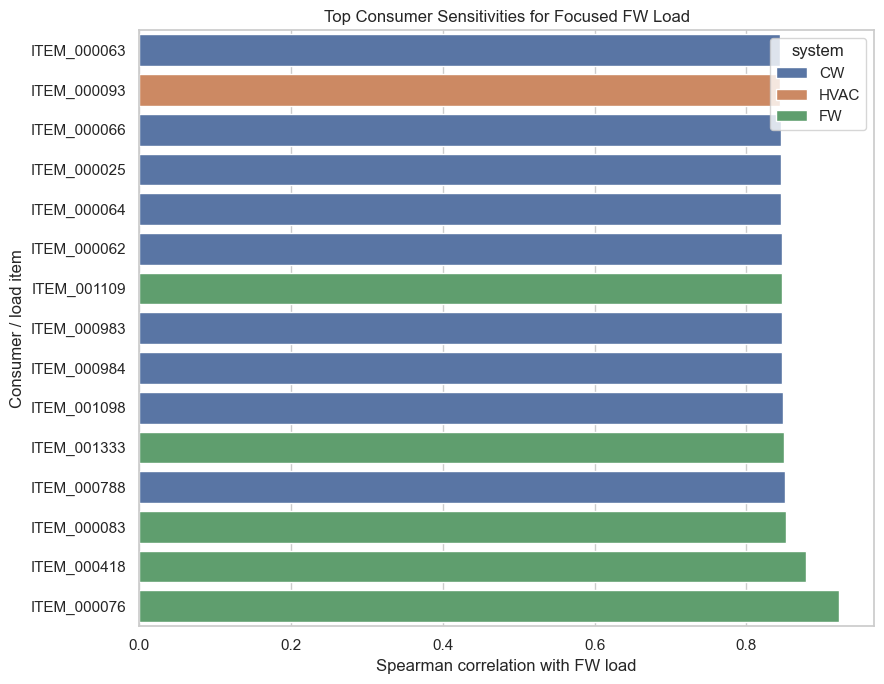

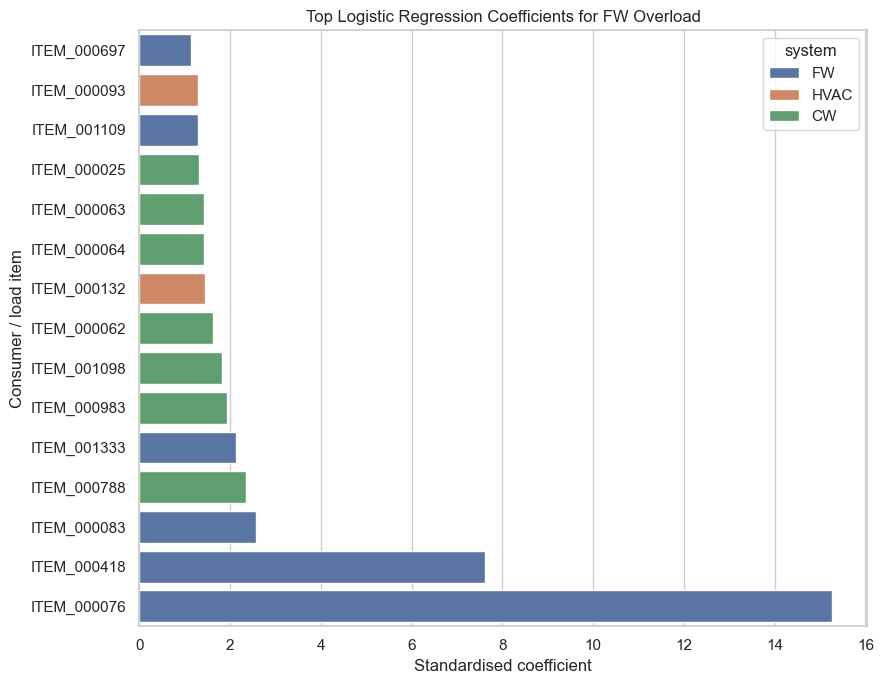

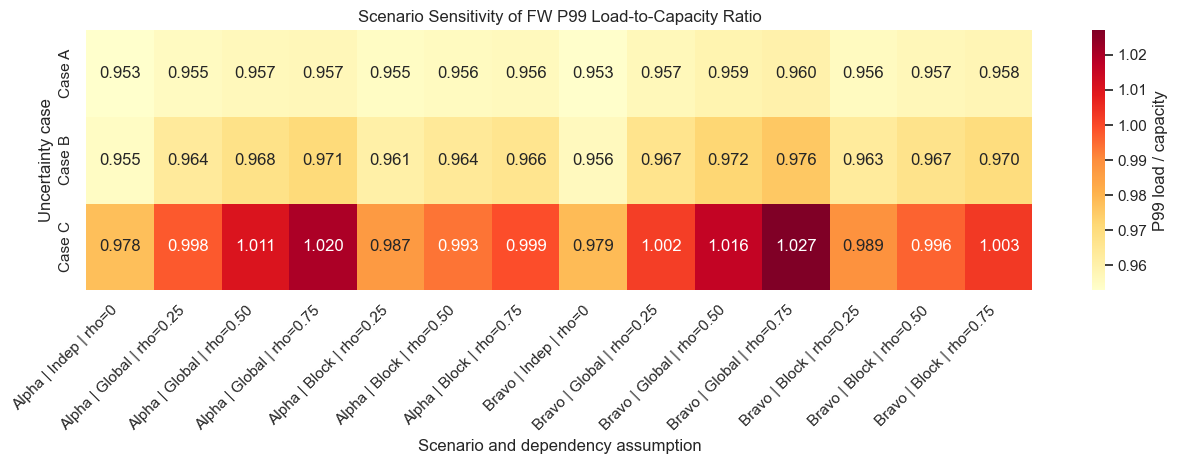

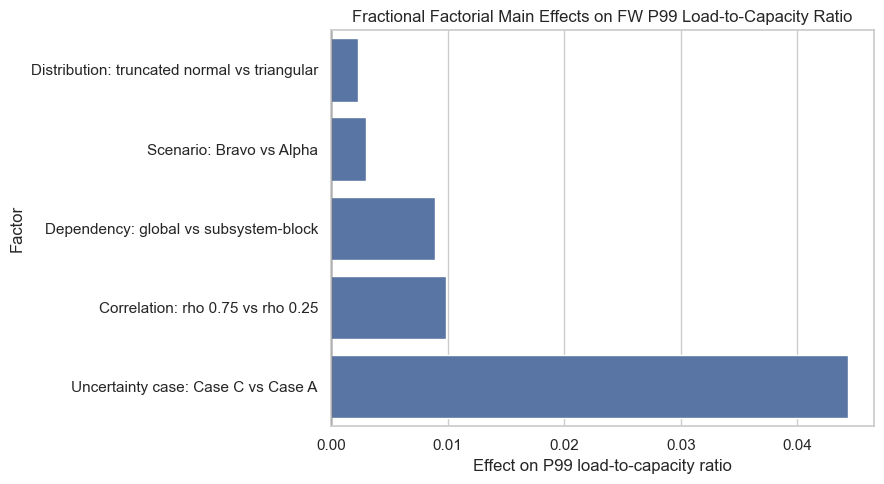

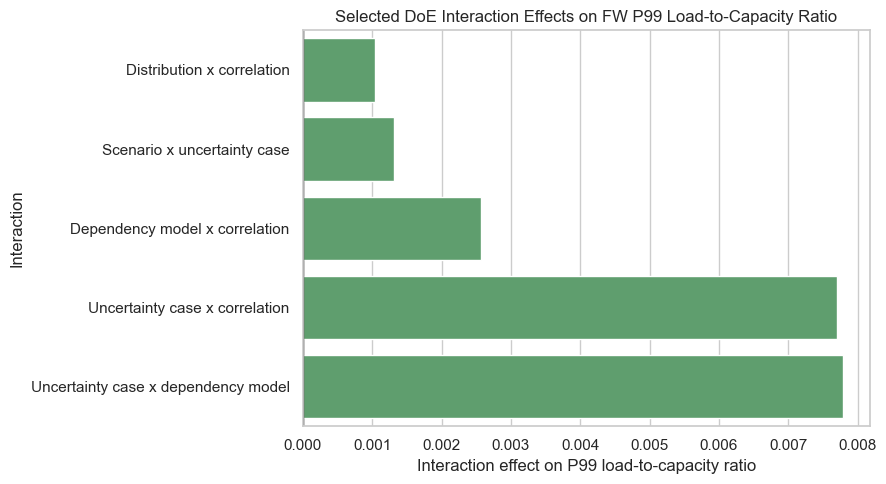

In [11]:
if plotting_available:
    sns.set_theme(style="whitegrid")

    plt.figure(figsize=(9, 7))
    plot_spearman = top_spearman.sort_values("spearman_fw_load", ascending=True).tail(15)
    sns.barplot(
        data=plot_spearman,
        x="spearman_fw_load",
        y="item_description",
        hue="system",
        dodge=False,
    )
    plt.title("Top Consumer Sensitivities for Focused FW Load")
    plt.xlabel("Spearman correlation with FW load")
    plt.ylabel("Consumer / load item")
    plt.tight_layout()
    plt.savefig(figures_output_path / "sensitivity_top_spearman_fw_load.png", dpi=150, bbox_inches="tight")
    plt.show()

    if not logistic_coefficients.empty:
        plt.figure(figsize=(9, 7))
        plot_logistic = logistic_coefficients.sort_values("standardised_coefficient", ascending=True).tail(15)
        sns.barplot(
            data=plot_logistic,
            x="standardised_coefficient",
            y="item_description",
            hue="system",
            dodge=False,
        )
        plt.title("Top Logistic Regression Coefficients for FW Overload")
        plt.xlabel("Standardised coefficient")
        plt.ylabel("Consumer / load item")
        plt.tight_layout()
        plt.savefig(figures_output_path / "sensitivity_logistic_regression_coefficients.png", dpi=150, bbox_inches="tight")
        plt.show()

    heatmap_data = scenario_sensitivity[
        (scenario_sensitivity["subsystem"] == "FW") &
        (scenario_sensitivity["distribution_model"] == "Truncated normal")
    ].copy()
    heatmap_data["scenario_label"] = heatmap_data["scenario"].map({
        "Scenario Alpha": "Alpha",
        "Scenario Bravo": "Bravo",
    })
    heatmap_data["case_label"] = heatmap_data["margin_case"].map({
        "Case A - CUM": "Case A",
        "Case B - CMM + CUM": "Case B",
        "Case C - CMM + CUM + DBM + IGM": "Case C",
    })
    heatmap_data["dependency_label"] = heatmap_data["dependency_model"].map({
        "Independent": "Indep",
        "Global Gaussian copula": "Global",
        "Subsystem-block Gaussian copula": "Block",
    })
    heatmap_data["rho_label"] = heatmap_data["rho"].map({
        0.0: "0",
        0.25: "0.25",
        0.5: "0.50",
        0.75: "0.75",
    })
    heatmap_data["assumption_label"] = (
        heatmap_data["scenario_label"] + " | " +
        heatmap_data["dependency_label"] + " | rho=" +
        heatmap_data["rho_label"]
    )

    heatmap_pivot = heatmap_data.pivot_table(
        index="case_label",
        columns="assumption_label",
        values="p99_load_to_capacity_ratio",
        aggfunc="max",
    )

    ordered_columns = []
    for scenario_label in ["Alpha", "Bravo"]:
        ordered_columns.append(f"{scenario_label} | Indep | rho=0")
        for dependency_label in ["Global", "Block"]:
            for rho_label in ["0.25", "0.50", "0.75"]:
                ordered_columns.append(f"{scenario_label} | {dependency_label} | rho={rho_label}")
    heatmap_pivot = heatmap_pivot.reindex(
        index=["Case A", "Case B", "Case C"],
        columns=[column for column in ordered_columns if column in heatmap_pivot.columns],
    )

    plt.figure(figsize=(13, 4.8))
    sns.heatmap(
        heatmap_pivot,
        annot=True,
        fmt=".3f",
        cmap="YlOrRd",
        cbar_kws={"label": "P99 load / capacity"},
    )
    plt.title("Scenario Sensitivity of FW P99 Load-to-Capacity Ratio")
    plt.xlabel("Scenario and dependency assumption")
    plt.ylabel("Uncertainty case")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.savefig(figures_output_path / "sensitivity_scenario_heatmap.png", dpi=150, bbox_inches="tight")
    plt.show()

    plt.figure(figsize=(9, 5))
    plot_effects = doe_effects.sort_values("effect", ascending=True)
    sns.barplot(
        data=plot_effects,
        x="effect",
        y="term",
        color="#4c72b0",
    )
    plt.axvline(0, color="black", linewidth=1)
    plt.title("Fractional Factorial Main Effects on FW P99 Load-to-Capacity Ratio")
    plt.xlabel("Effect on P99 load-to-capacity ratio")
    plt.ylabel("Factor")
    plt.tight_layout()
    plt.savefig(figures_output_path / "sensitivity_fractional_factorial_effects.png", dpi=150, bbox_inches="tight")
    plt.show()

    plt.figure(figsize=(9, 5))
    plot_interactions = doe_interactions.sort_values("effect", ascending=True)
    sns.barplot(
        data=plot_interactions,
        x="effect",
        y="term",
        color="#55a868",
    )
    plt.axvline(0, color="black", linewidth=1)
    plt.title("Selected DoE Interaction Effects on FW P99 Load-to-Capacity Ratio")
    plt.xlabel("Interaction effect on P99 load-to-capacity ratio")
    plt.ylabel("Interaction")
    plt.tight_layout()
    plt.savefig(figures_output_path / "sensitivity_fractional_factorial_interactions.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("Skipping plots because matplotlib and seaborn are not installed.")


## Interpretation


In [12]:
sensitivity_key_findings = pd.DataFrame([
    {
        "finding": "Worst modelling assumption",
        "evidence": scenario_sensitivity.iloc[0][["scenario", "margin_case", "distribution_model", "dependency_model", "rho", "subsystem", "p99_load_to_capacity_ratio"]].to_dict(),
    },
    {
        "finding": "Strongest consumer / load item",
        "evidence": consumer_screening.iloc[0][["item_description", "system", "spearman_fw_load", "sample_p99_kw"]].to_dict(),
    },
    {
        "finding": "Largest DoE main effect",
        "evidence": doe_effects.iloc[0][["term", "effect"]].to_dict(),
    },
    {
        "finding": "Largest selected DoE interaction",
        "evidence": doe_interactions.iloc[0][["term", "effect"]].to_dict(),
    },
])

sensitivity_key_findings.to_csv(tables_output_path / "sensitivity_key_findings.csv", index=False)
display(sensitivity_key_findings)


,finding,evidence
0,Worst modelling assumption,"{'scenario': 'Scenario Bravo', 'margin_case': ..."
1,Strongest consumer / load item,"{'item_description': 'ITEM_000076', 'system': ..."
2,Largest DoE main effect,"{'term': 'Uncertainty case: Case C vs Case A',..."
3,Largest selected DoE interaction,{'term': 'Uncertainty case x dependency model'...


## Notebook 07 conclusion

This notebook connects the system-level Monte Carlo results to the assumptions and consumers that drive the risk result.

The consumer screening identifies the load rows most strongly associated with the final FW response. The scenario sensitivity analysis then shows which modelling assumptions create the highest FW P99 load-to-capacity ratios. Logistic regression is used only where overload events exist, and the fractional factorial DoE provides a compact screening view of the main modelling assumptions and selected interactions.

The DoE is therefore not used to estimate failure probabilities. It is used to identify influential consumers, highlight interactions affecting proximity to capacity, and support interpretation of the Monte Carlo results.

Notebook 08 can now use these results to discuss verification and convergence.
